In [38]:
import pandas as pd
import numpy as np
import datetime
from synthdid.synthdid import Synthdid

In [44]:
data = pd.read_csv('../temporary/data_sdid.csv', parse_dates=['time'])
country_data = pd.read_csv('../temporary/country_data.csv')

In [31]:
data.head()

,user_cc,time,outflow,time_number,country_number,BJ,CA,CM,DE,GB,GH,IN,NG,NL,ZA
0,AD,2017-03-12,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,AD,2017-03-19,0.0,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,AD,2017-03-26,0.0,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,AD,2017-04-02,0.0,4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,AD,2017-04-09,0.0,5,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [24]:
def initialize_sdid(data, window_start, window_end, treated_unit, treatment_start):
    df = data[(data['time'] >= window_start) & (data['time'] <= window_end)].copy()

    #create dummy for treatment
    df['treated'] = ((df['user_cc'] == treated_unit) & (df['time'] >= treatment_start)).astype(int)
    
    #intialize SDID object
    sdid = Synthdid(data = df, unit = "user_cc", time = "time", treatment="treated", outcome="outflow")
    return sdid

In [48]:
test = initialize_sdid(data=data, window_start = '2020-01-01', window_end='2020-06-07', treated_unit='US', treatment_start='2020-04-09')

TypeError: The DType <class 'numpy.dtype[datetime64]'> could not be promoted by <class 'numpy.dtype[float64]'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtype[datetime64]'>, <class 'numpy.dtype[float64]'>)

In [28]:
from synthdid.get_data import california_prop99

cali_data = california_prop99()

In [29]:
cali_data

,State,Year,PacksPerCapita,treated
0,Alabama,1970,89.800003,0
1,Arkansas,1970,100.300003,0
2,Colorado,1970,124.800003,0
3,Connecticut,1970,120.000000,0
4,Delaware,1970,155.000000,0
...,...,...,...,...
1204,Virginia,2000,96.699997,0
1205,West Virginia,2000,107.900002,0
1206,Wisconsin,2000,80.099998,0
1207,Wyoming,2000,90.500000,0


# CAUSAL INF FOR THE BRAVE AND TRUE

In [26]:
pip install toolz seaborn cvxpy joblib

     -------------------------------------- 301.8/301.8 kB 9.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
from toolz import curry, partial
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import cvxpy as cp

import warnings
warnings.filterwarnings('ignore')

from matplotlib import style
style.use("ggplot")

pd.set_option('display.max_columns', 10)

In [53]:
data = (pd.read_csv("../temporary/smoking.csv")[["state", "year", "cigsale", "california", "after_treatment"]]
        .rename(columns={"california": "treated"})
        .replace({"state": {3: "california"}}))

data.head()

,state,year,cigsale,treated,after_treatment
0,1,1970,89.800003,False,False
1,1,1971,95.400002,False,False
2,1,1972,101.099998,False,False
3,1,1973,102.900002,False,False
4,1,1974,108.199997,False,False


In [9]:
data.query("state=='california'").query("year.between(1986, 1990)")

,state,year,cigsale,treated,after_treatment
78,california,1986,99.699997,True,False
79,california,1987,97.500000,True,False
80,california,1988,90.099998,True,False
81,california,1989,82.400002,True,True
82,california,1990,77.800003,True,True


In [54]:
def fit_time_weights(data, outcome_col, year_col, state_col, treat_col, post_col):
        
        control = data.query(f"~{treat_col}")
        
        # pivot the data to the (T_pre, N_co) matrix representation
        y_pre = (control
                 .query(f"~{post_col}")
                 .pivot(year_col, state_col, outcome_col))
        
        # group post-treatment time period by units to have a (1, N_co) vector.
        y_post_mean = (control
                       .query(f"{post_col}")
                       .groupby(state_col)
                       [outcome_col]
                       .mean()
                       .values)
        
        # add a (1, N_co) vector of 1 to the top of the matrix, to serve as the intercept.
        X = np.concatenate([np.ones((1, y_pre.shape[1])), y_pre.values], axis=0)
        
        # estimate time weights
        w = cp.Variable(X.shape[0])
        objective = cp.Minimize(cp.sum_squares(w@X - y_post_mean))
        constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        problem = cp.Problem(objective, constraints)
        problem.solve(verbose=True)
        
        # print("Intercept: ", w.value[0])
        return pd.Series(w.value[1:], # remove intercept
                         name="time_weights",
                         index=y_pre.index)

In [55]:

time_weights = fit_time_weights(data,
                                outcome_col="cigsale",
                                year_col="year",
                                state_col="state",
                                treat_col="treated",
                                post_col="after_treatment")

time_weights.round(3).tail()

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Jan 05 12:21:24 PM: Your problem has 20 variables, 20 constraints, and 0 parameters.
(CVXPY) Jan 05 12:21:24 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 05 12:21:24 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 05 12:21:24 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 05 12:21:24 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jan 05 12:21:24 PM: Compiling problem (target solver=OSQP).
(CV

year
1984   -0.000
1985   -0.000
1986    0.366
1987    0.206
1988    0.427
Name: time_weights, dtype: float64

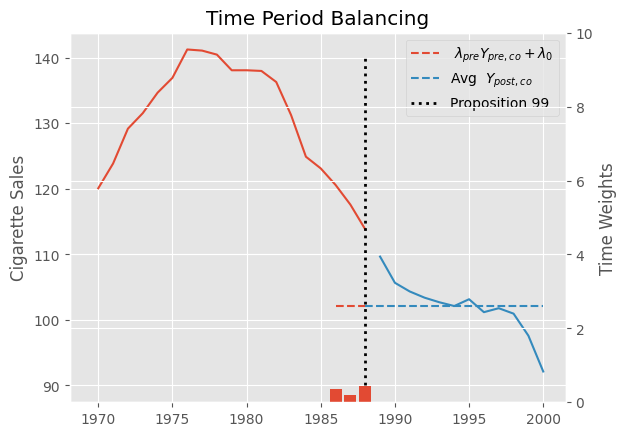

In [13]:

fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(data.query("~treated").query("~after_treatment").groupby("year")["cigsale"].mean())
ax.plot(data.query("~treated").query("after_treatment").groupby("year")["cigsale"].mean())

intercept = -15.023877689807628
ax.hlines((data.query("~treated").query("~after_treatment").groupby("year")["cigsale"].mean() * time_weights).sum() - 15, 1986, 1988,
          color="C0", ls="dashed", label=""" $\lambda_{pre} Y_{pre, co} + \lambda_0$""")
ax.hlines(data.query("~treated").query("after_treatment").groupby("year")["cigsale"].mean().mean(), 1988, 2000,
          color="C1", ls="dashed", label="""Avg  $Y_{post, co}$""")
ax.vlines(x=1988, ymin=90, ymax=140, linestyle=":", lw=2, label="Proposition 99", color="black")
plt.legend()

plt.title("Time Period Balancing")
plt.ylabel("Cigarette Sales");

ax2 = ax.twinx()
ax2.bar(time_weights.index, time_weights, label="$\lambda$")
ax2.set_ylim(0,10)
ax2.set_ylabel("Time Weights");

In [14]:
def calculate_regularization(data, outcome_col, year_col, state_col, treat_col, post_col):
    
    n_treated_post = data.query(post_col).query(treat_col).shape[0]
    
    first_diff_std = (data
                      .query(f"~{post_col}")
                      .query(f"~{treat_col}")
                      .sort_values(year_col)
                      .groupby(state_col)
                      [outcome_col]
                      .diff()
                      .std())
    
    return n_treated_post**(1/4) * first_diff_std

In [15]:
def fit_unit_weights(data, outcome_col, year_col, state_col, treat_col, post_col):
    
    zeta = calculate_regularization(data, outcome_col, year_col, state_col, treat_col, post_col)
    pre_data = data.query(f"~{post_col}")
    
    # pivot the data to the (T_pre, N_co) matrix representation
    y_pre_control = (pre_data
                     .query(f"~{treat_col}")
                     .pivot(year_col, state_col, outcome_col))
    
    # group treated units by time periods to have a (T_pre, 1) vector.
    y_pre_treat_mean = (pre_data
                        .query(f"{treat_col}")
                        .groupby(year_col)
                        [outcome_col]
                        .mean())
    
    # add a (T_pre, 1) column to the begining of the (T_pre, N_co) matrix to serve as intercept
    T_pre = y_pre_control.shape[0]
    X = np.concatenate([np.ones((T_pre, 1)), y_pre_control.values], axis=1) 
    
    # estimate unit weights. Notice the L2 penalty using zeta
    w = cp.Variable(X.shape[1])
    objective = cp.Minimize(cp.sum_squares(X@w - y_pre_treat_mean.values) + T_pre*zeta**2 * cp.sum_squares(w[1:]))
    constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
    
    problem = cp.Problem(objective, constraints)
    problem.solve(verbose=False)
    
    # print("Intercept:", w.value[0])
    return pd.Series(w.value[1:], # remove intercept
                     name="unit_weights",
                     index=y_pre_control.columns)

In [16]:
unit_weights = fit_unit_weights(data,
                                outcome_col="cigsale",
                                year_col="year",
                                state_col="state",
                                treat_col="treated",
                                post_col="after_treatment")

unit_weights.round(3).head()

state
1   -0.000
2   -0.000
4    0.057
5    0.078
6    0.070
Name: unit_weights, dtype: float64

NameError: name 'sc' is not defined

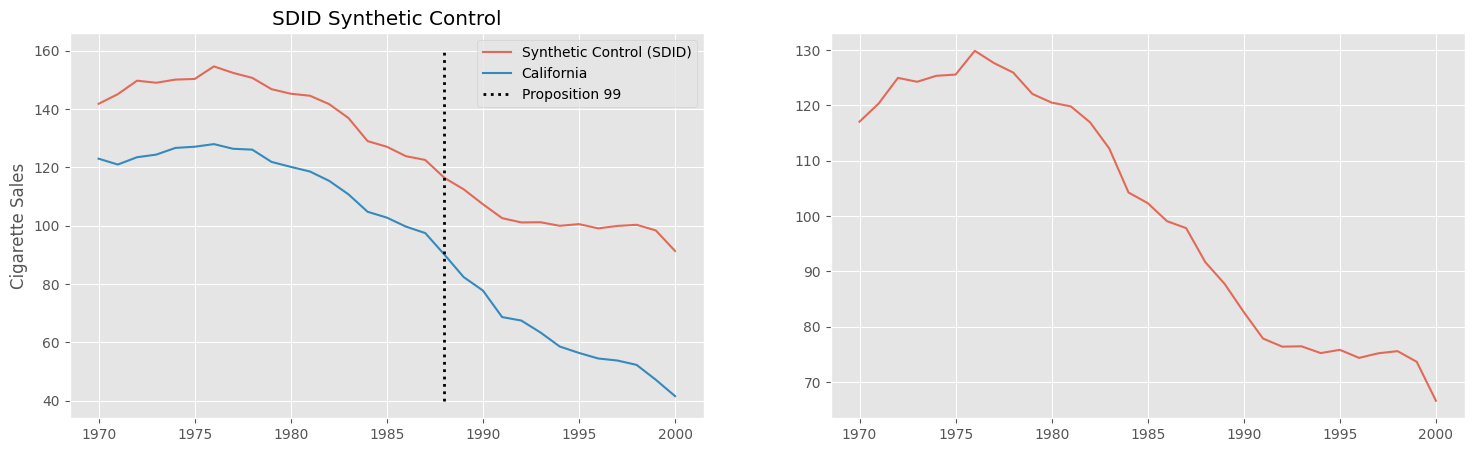

In [17]:
intercept = -24.75035353644767
sc_did = data_piv.drop(columns="california").values @ unit_weights.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,5))

ax1.plot(data_piv.index, sc_did, label="Synthetic Control (SDID)", color="C0", alpha=.8)
ax1.plot(data_piv["california"], label="California", color="C1")
ax1.vlines(x=1988, ymin=40, ymax=160, linestyle=":", lw=2, label="Proposition 99", color="black")

ax1.legend()
ax1.set_title("SDID Synthetic Control")
ax1.set_ylabel("Cigarette Sales");

ax2.plot(data_piv.index, sc_did+intercept, label="Synthetic Control (SDID) + $w_0$", color="C0", alpha=.8)
ax2.plot(data_piv.index, sc, label="Traditional SC", color="C0", ls="dashed")
ax2.plot(data_piv["california"], label="California", color="C1")
ax2.vlines(x=1988, ymin=40, ymax=160, linestyle=":", lw=2, label="Proposition 99", color="black")
ax2.legend()
ax2.set_title("SDID and Traditional SCs");

In [18]:
def join_weights(data, unit_w, time_w, year_col, state_col, treat_col, post_col):
    return (
        data
        .set_index([year_col, state_col])
        .join(time_w)
        .join(unit_w)
        .reset_index()
        .fillna({time_w.name: 1 / len(pd.unique(data.query(f"{post_col}")[year_col])),
                 unit_w.name: 1 / len(pd.unique(data.query(f"{treat_col}")[state_col]))})
        .assign(**{"weights": lambda d: (d[time_w.name] * d[unit_w.name]).round(10)})
        .astype({treat_col: int, post_col: int}))

In [19]:
did_data = join_weights(data, unit_weights, time_weights,
                        year_col="year",
                        state_col="state",
                        treat_col="treated",
                        post_col="after_treatment")

did_data.head()

,year,state,cigsale,treated,after_treatment,time_weights,unit_weights,weights
0,1970,1,89.800003,0,0,-4.600034e-14,-1.360835e-16,0.0
1,1971,1,95.400002,0,0,-4.582315e-14,-1.360835e-16,0.0
2,1972,1,101.099998,0,0,-5.274190e-14,-1.360835e-16,0.0
3,1973,1,102.900002,0,0,-5.766356e-14,-1.360835e-16,0.0
4,1974,1,108.199997,0,0,-5.617979e-14,-1.360835e-16,0.0


In [20]:

did_model = smf.wls("cigsale ~ after_treatment*treated",
                    data=did_data,
                    weights=did_data["weights"]+1e-10).fit()

did_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,120.4060,1.272,94.665,0.000,117.911,122.901
after_treatment,-19.1905,1.799,-10.669,0.000,-22.720,-15.661
treated,-25.2601,1.799,-14.043,0.000,-28.789,-21.731
after_treatment:treated,-15.6054,2.544,-6.135,0.000,-20.596,-10.615


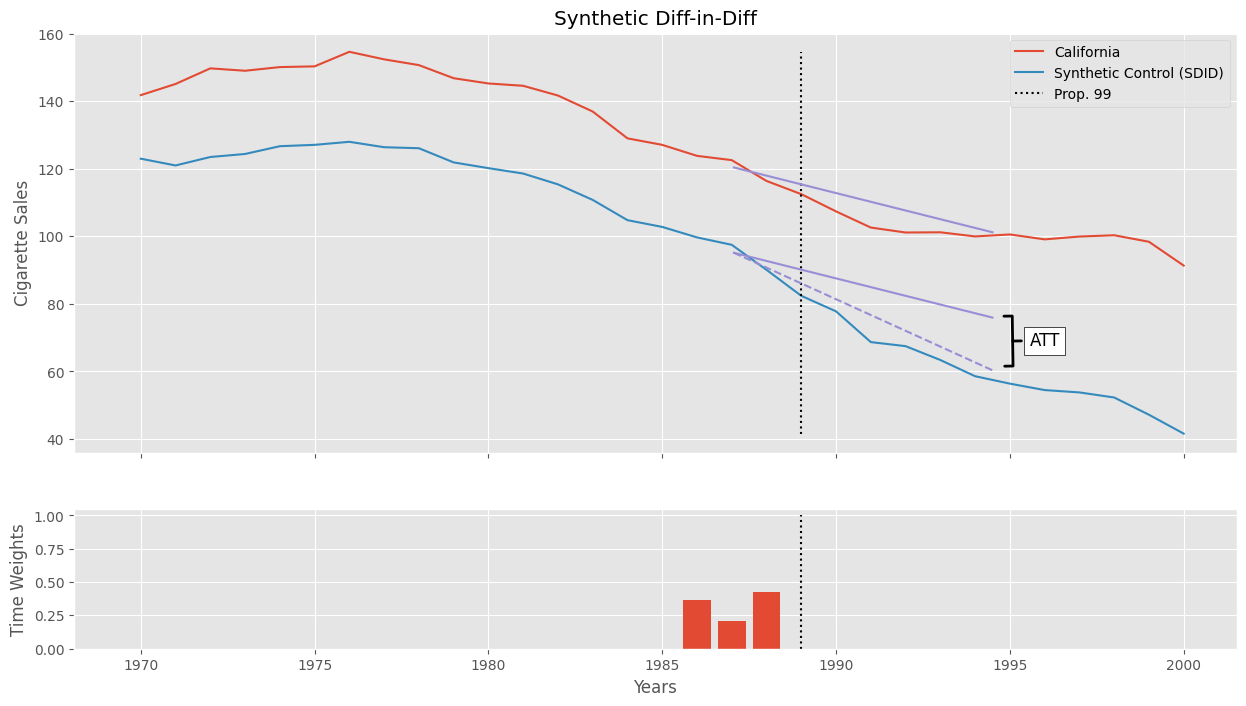

In [21]:
avg_pre_period = (time_weights * time_weights.index).sum()
avg_post_period = 1989 + (2000 - 1989) / 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data_piv.index, sc_did, label="California")
ax1.plot(data_piv.index, data_piv["california"], label="Synthetic Control (SDID)")
ax1.vlines(1989, data_piv["california"].min(), sc_did.max(), color="black", ls="dotted", label="Prop. 99")

pre_sc = did_model.params["Intercept"]
post_sc = pre_sc + did_model.params["after_treatment"]
pre_treat = pre_sc + did_model.params["treated"]
post_treat = post_sc + did_model.params["treated"] + did_model.params["after_treatment:treated"]

sc_did_y0 = pre_treat + (post_sc - pre_sc)

ax1.plot([avg_pre_period, avg_post_period], [pre_sc, post_sc], color="C2")
ax1.plot([avg_pre_period, avg_post_period], [pre_treat, post_treat], color="C2", ls="dashed")
ax1.plot([avg_pre_period, avg_post_period], [pre_treat, sc_did_y0], color="C2")

ax1.annotate('ATT', xy=(1995, 69), xytext=(1996, 66.5), 
            fontsize=12, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', color='k'),
            arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=0.5', lw=2.0, color='k'))

ax1.legend()
ax1.set_title("Synthetic Diff-in-Diff")
ax1.set_ylabel("Cigarette Sales")

ax2.bar(time_weights.index, time_weights)
ax2.vlines(1989, 0, 1, color="black", ls="dotted")
ax2.set_ylabel("Time Weights")
ax2.set_xlabel("Years");

In [22]:
def synthetic_diff_in_diff(data, outcome_col, year_col, state_col, treat_col, post_col):
    
    # find the unit weights
    unit_weights = fit_unit_weights(data,
                                    outcome_col=outcome_col,
                                    year_col=year_col,
                                    state_col=state_col,
                                    treat_col=treat_col,
                                    post_col=post_col)
    
    # find the time weights
    time_weights = fit_time_weights(data,
                                    outcome_col=outcome_col,
                                    year_col=year_col,
                                    state_col=state_col,
                                    treat_col=treat_col,
                                    post_col=post_col)

    # join weights into DiD Data
    did_data = join_weights(data, unit_weights, time_weights,
                            year_col=year_col,
                            state_col=state_col,
                            treat_col=treat_col,
                            post_col=post_col)
    
    # run DiD
    formula = f"{outcome_col} ~ {post_col}*{treat_col}"
    did_model = smf.wls(formula, data=did_data, weights=did_data["weights"]+1e-10).fit()
    
    return did_model.params[f"{post_col}:{treat_col}"]


synthetic_diff_in_diff(data, 
                       outcome_col="cigsale",
                       year_col="year",
                       state_col="state",
                       treat_col="treated",
                       post_col="after_treatment")

-15.605397234587086

In [32]:

effects = {year: synthetic_diff_in_diff(data.query(f"~after_treatment|(year=={year})"), 
                                        outcome_col="cigsale",
                                        year_col="year",
                                        state_col="state",
                                        treat_col="treated",
                                        post_col="after_treatment")
           for year in range(1989, 2001)}

effects = pd.Series(effects)

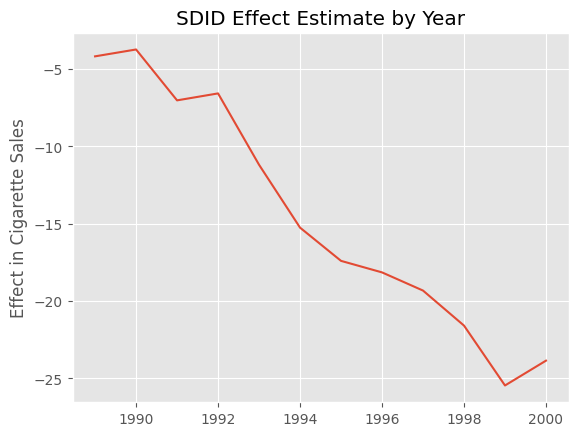

In [33]:
plt.plot(effects);
plt.ylabel("Effect in Cigarette Sales")
plt.title("SDID Effect Estimate by Year");

In [23]:

def make_random_placebo(data, state_col, treat_col):
    control = data.query(f"~{treat_col}")
    states = control[state_col].unique()
    placebo_state = np.random.choice(states)
    return control.assign(**{treat_col: control[state_col] == placebo_state})

In [24]:
np.random.seed(1)
placebo_data = make_random_placebo(data, state_col="state", treat_col="treated")

placebo_data.query("treated").tail()

,state,year,cigsale,treated,after_treatment
1204,39,1996,110.300003,True,True
1205,39,1997,108.800003,True,True
1206,39,1998,102.900002,True,True
1207,39,1999,104.800003,True,True
1208,39,2000,90.500000,True,True


In [27]:
from joblib import Parallel, delayed # for parallel processing


def estimate_se(data, outcome_col, year_col, state_col, treat_col, post_col, bootstrap_rounds=400, seed=0, njobs=4):
    np.random.seed(seed=seed)
    
    sdid_fn = partial(synthetic_diff_in_diff,
                      outcome_col=outcome_col,
                      year_col=year_col,
                      state_col=state_col,
                      treat_col=treat_col,
                      post_col=post_col)
    
    effects = Parallel(n_jobs=njobs)(delayed(sdid_fn)(make_random_placebo(data, state_col=state_col, treat_col=treat_col))
                                     for _ in range(bootstrap_rounds))
    
    return np.std(effects, axis=0)

In [28]:
effect = synthetic_diff_in_diff(data,
                                outcome_col="cigsale",
                                year_col="year",
                                state_col="state",
                                treat_col="treated",
                                post_col="after_treatment")


se = estimate_se(data,
                 outcome_col="cigsale",
                 year_col="year",
                 state_col="state",
                 treat_col="treated",
                 post_col="after_treatment")

In [29]:
print(f"Effect: {effect}")
print(f"Standard Error: {se}")
print(f"90% CI: ({effect-1.65*se}, {effect+1.65*se})")

Effect: -15.605397234587086
Standard Error: 9.912089736240304
90% CI: (-31.96034529938359, 0.7495508302094169)


In [30]:

standard_errors = {year: estimate_se(data.query(f"~after_treatment|(year=={year})"), 
                                     outcome_col="cigsale",
                                     year_col="year",
                                     state_col="state",
                                     treat_col="treated",
                                     post_col="after_treatment")
                   for year in range(1989, 2001)}

standard_errors = pd.Series(standard_errors)

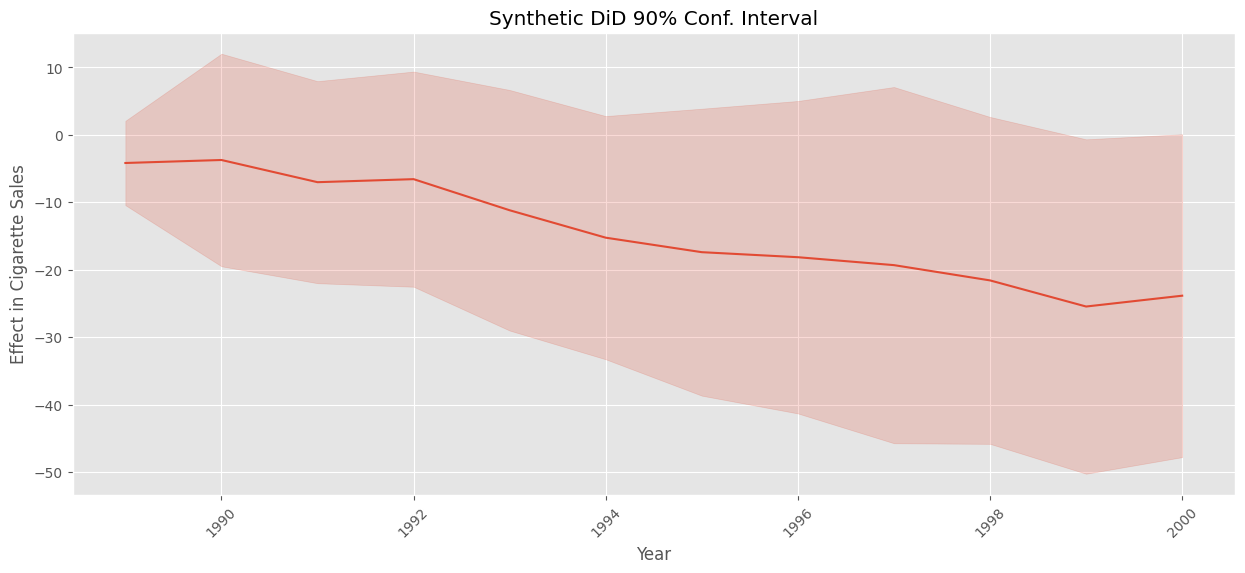

In [34]:
plt.figure(figsize=(15,6))

plt.plot(effects, color="C0")
plt.fill_between(effects.index, effects-1.65*standard_errors, effects+1.65*standard_errors, alpha=0.2,  color="C0")

plt.ylabel("Effect in Cigarette Sales")
plt.xlabel("Year")
plt.title("Synthetic DiD 90% Conf. Interval")
plt.xticks(rotation=45);

# Test with my data

In [56]:

data_sdid = pd.read_csv('../temporary/data_sdid.csv', parse_dates=['time'])
country_data = pd.read_csv('../temporary/country_data.csv')

In [57]:
data_sdid.head()

,user_cc,time,outflow,time_number,country_number,...,GH,IN,NG,NL,ZA
0,AD,2017-03-12,0.0,1,1,...,0.0,0.0,1.0,0.0,0.0
1,AD,2017-03-19,0.0,2,1,...,0.0,0.0,1.0,0.0,0.0
2,AD,2017-03-26,0.0,3,1,...,0.0,0.0,1.0,0.0,0.0
3,AD,2017-04-02,0.0,4,1,...,0.0,0.0,1.0,0.0,0.0
4,AD,2017-04-09,0.0,5,1,...,0.0,0.0,1.0,0.0,0.0


In [68]:
def format_data_sdid(data, window_start, window_end, treated_unit, treatment_start):
    df = data[(data['time'] >= window_start) & (data['time'] <= window_end)].copy()

    #create dummy for treatment
    df['treated'] = (df['user_cc'] == treated_unit).astype(bool)
    df['after_treatment'] = (df['time'] >= treatment_start)

    #filter out zeros
    df = df[df.groupby('user_cc')['outflow'].transform('min') > 0]
    
    return df

In [73]:
test_df = format_data_sdid(data=data_sdid, window_start = '2019-10-01', window_end='2020-08-07', treated_unit='US', treatment_start='2020-04-09')


In [74]:
test_df

,user_cc,time,outflow,time_number,country_number,...,NG,NL,ZA,treated,after_treatment
424,AE,2019-10-06,6785.403041,135,2,...,0.621855,0.004529,0.010112,False,False
425,AE,2019-10-13,7531.610820,136,2,...,0.621855,0.004529,0.010112,False,False
426,AE,2019-10-20,6329.624662,137,2,...,0.621855,0.004529,0.010112,False,False
427,AE,2019-10-27,8757.023185,138,2,...,0.621855,0.004529,0.010112,False,False
428,AE,2019-11-03,10792.959988,139,2,...,0.621855,0.004529,0.010112,False,False
...,...,...,...,...,...,...,...,...,...,...,...
61363,ZA,2020-07-05,27828.672086,174,212,...,0.619259,0.005681,0.000000,False,True
61364,ZA,2020-07-12,17696.901959,175,212,...,0.619259,0.005681,0.000000,False,True
61365,ZA,2020-07-19,25666.341653,176,212,...,0.619259,0.005681,0.000000,False,True
61366,ZA,2020-07-26,19615.557671,177,212,...,0.619259,0.005681,0.000000,False,True


In [75]:
test_df[test_df['treated'] == True]

,user_cc,time,outflow,time_number,country_number,...,NG,NL,ZA,treated,after_treatment
57554,US,2019-10-06,413116.274904,135,199,...,0.786188,0.006847,0.012184,True,False
57555,US,2019-10-13,412490.869062,136,199,...,0.786188,0.006847,0.012184,True,False
57556,US,2019-10-20,384477.874070,137,199,...,0.786188,0.006847,0.012184,True,False
57557,US,2019-10-27,457478.772779,138,199,...,0.786188,0.006847,0.012184,True,False
57558,US,2019-11-03,440371.083633,139,199,...,0.786188,0.006847,0.012184,True,False
57559,US,2019-11-10,404111.055485,140,199,...,0.786188,0.006847,0.012184,True,False
57560,US,2019-11-17,415696.091173,141,199,...,0.786188,0.006847,0.012184,True,False
57561,US,2019-11-24,427545.862405,142,199,...,0.786188,0.006847,0.012184,True,False
57562,US,2019-12-01,503321.379117,143,199,...,0.786188,0.006847,0.012184,True,False
57563,US,2019-12-08,416122.295084,144,199,...,0.786188,0.006847,0.012184,True,False


In [46]:
unit_weights = fit_unit_weights(test_df,
                                outcome_col='outflow',
                                year_col='time',
                                state_col='user_cc',
                                treat_col='treated',
                                post_col='after_treatment')

In [98]:
def fit_time_weights(data, outcome_col, year_col, state_col, treat_col, post_col):
        
        control = data.query(f"~{treat_col}")
        
        # pivot the data to the (T_pre, N_co) matrix representation
        y_pre = (control
                 .query(f"~{post_col}")
                 .pivot(year_col, state_col, outcome_col))
        
        print(y_pre)
        
        # group post-treatment time period by units to have a (1, N_co) vector.
        y_post_mean = (control
                       .query(f"{post_col}")
                       .groupby(state_col)
                       [outcome_col]
                       .mean()
                       .values)
        
        # add a (1, N_co) vector of 1 to the top of the matrix, to serve as the intercept.
        X = np.concatenate([np.ones((1, y_pre.shape[1])), y_pre.values], axis=0)

        print("X shape:", X.shape)
        print("y_post_mean shape:", y_post_mean.shape)
        print("Are there NaNs in y_pre?", y_pre.isnull().any().any())
        print("Are there NaNs in y_post_mean?", np.isnan(y_post_mean).any())

        
        # estimate time weights
        w = cp.Variable(X.shape[0])
        objective = cp.Minimize(cp.sum_squares(w@X - y_post_mean))
        constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        # constraints = [cp.sum(w[1:]) == 1]      
        # constraints = [w[1:] >= 0]
        problem = cp.Problem(objective, constraints)
        problem.solve(verbose=True)
        
        # print("Intercept: ", w.value[0])
        return pd.Series(w.value[1:], # remove intercept
                         name="time_weights",
                         index=y_pre.index)

In [99]:
#MY DATA
time_weights = fit_time_weights(test_df,
                                outcome_col='outflow',
                                year_col='time',
                                state_col='user_cc',
                                treat_col='treated',
                                post_col='after_treatment')

user_cc               AE          AL          AR           AU           BD  \
time                                                                         
2019-10-06   6785.403041  448.191142  533.978219  3741.052065   296.807075   
2019-10-13   7531.610820  264.420365  462.063827  3133.242041   348.465493   
2019-10-20   6329.624662  285.397568  155.994995  3240.436329   332.017770   
2019-10-27   8757.023185  481.813073  407.723609  2730.773001  1402.740422   
2019-11-03  10792.959988  119.355649  379.796142  3551.521361  1408.550404   
2019-11-10   8743.171706   19.204625  491.925812  2356.304319   883.221906   
2019-11-17  10630.751151   86.965430  235.983773  2780.220237   715.795310   
2019-11-24  10575.583216  117.110115  214.601148  3191.607999   324.351364   
2019-12-01  12372.501920  146.851545  681.991202  2238.724447   523.297069   
2019-12-08  10290.097404  300.840105  562.757026  3311.865452  1049.261697   
2019-12-15  11001.568635  275.576598  304.484893  2535.325038   

TypeError: 'NoneType' object is not subscriptable

In [100]:
#CALI DATA
time_weights = fit_time_weights(data,
                                outcome_col="cigsale",
                                year_col="year",
                                state_col="state",
                                treat_col="treated",
                                post_col="after_treatment")

state          1           2           4           5           6   ...  \
year                                                               ...   
1970    89.800003  100.300003  124.800003  120.000000  155.000000  ...   
1971    95.400002  104.099998  125.500000  117.599998  161.100006  ...   
1972   101.099998  103.900002  134.300003  110.800003  156.300003  ...   
1973   102.900002  108.000000  137.899994  109.300003  154.699997  ...   
1974   108.199997  109.699997  132.800003  112.400002  151.300003  ...   
1975   111.699997  114.800003  131.000000  110.199997  147.600006  ...   
1976   116.199997  119.099998  134.199997  113.400002  153.000000  ...   
1977   117.099998  122.599998  132.000000  117.300003  153.300003  ...   
1978   123.000000  127.300003  129.199997  117.500000  155.500000  ...   
1979   121.400002  126.500000  131.500000  117.400002  150.199997  ...   
1980   123.199997  131.800003  131.000000  118.000000  150.500000  ...   
1981   119.599998  128.699997  133.800

In [93]:
def synthetic_diff_in_diff(data, outcome_col, year_col, state_col, treat_col, post_col):
    
    # find the unit weights
    unit_weights = fit_unit_weights(data,
                                    outcome_col=outcome_col,
                                    year_col=year_col,
                                    state_col=state_col,
                                    treat_col=treat_col,
                                    post_col=post_col)
    
    # find the time weights
    time_weights = fit_time_weights(data,
                                    outcome_col=outcome_col,
                                    year_col=year_col,
                                    state_col=state_col,
                                    treat_col=treat_col,
                                    post_col=post_col)

    # join weights into DiD Data
    did_data = join_weights(data, unit_weights, time_weights,
                            year_col=year_col,
                            state_col=state_col,
                            treat_col=treat_col,
                            post_col=post_col)
    
    # run DiD
    formula = f"{outcome_col} ~ {post_col}*{treat_col}"
    did_model = smf.wls(formula, data=did_data, weights=did_data["weights"]+1e-10).fit()
    
    return did_model.params[f"{post_col}:{treat_col}"]

In [94]:
effect_cali = synthetic_diff_in_diff(data,
                                outcome_col="cigsale",
                                year_col="year",
                                state_col="state",
                                treat_col="treated",
                                post_col="after_treatment")

state          1           2           4           5           6   ...  \
year                                                               ...   
1970    89.800003  100.300003  124.800003  120.000000  155.000000  ...   
1971    95.400002  104.099998  125.500000  117.599998  161.100006  ...   
1972   101.099998  103.900002  134.300003  110.800003  156.300003  ...   
1973   102.900002  108.000000  137.899994  109.300003  154.699997  ...   
1974   108.199997  109.699997  132.800003  112.400002  151.300003  ...   
1975   111.699997  114.800003  131.000000  110.199997  147.600006  ...   
1976   116.199997  119.099998  134.199997  113.400002  153.000000  ...   
1977   117.099998  122.599998  132.000000  117.300003  153.300003  ...   
1978   123.000000  127.300003  129.199997  117.500000  155.500000  ...   
1979   121.400002  126.500000  131.500000  117.400002  150.199997  ...   
1980   123.199997  131.800003  131.000000  118.000000  150.500000  ...   
1981   119.599998  128.699997  133.800

LinAlgError: SVD did not converge

In [95]:
effect = synthetic_diff_in_diff(test_df,
                                outcome_col='outflow',
                                year_col='time',
                                state_col='user_cc',
                                treat_col='treated',
                                post_col='after_treatment')

user_cc               AE          AL          AR           AU           BD  \
time                                                                         
2019-10-06   6785.403041  448.191142  533.978219  3741.052065   296.807075   
2019-10-13   7531.610820  264.420365  462.063827  3133.242041   348.465493   
2019-10-20   6329.624662  285.397568  155.994995  3240.436329   332.017770   
2019-10-27   8757.023185  481.813073  407.723609  2730.773001  1402.740422   
2019-11-03  10792.959988  119.355649  379.796142  3551.521361  1408.550404   
2019-11-10   8743.171706   19.204625  491.925812  2356.304319   883.221906   
2019-11-17  10630.751151   86.965430  235.983773  2780.220237   715.795310   
2019-11-24  10575.583216  117.110115  214.601148  3191.607999   324.351364   
2019-12-01  12372.501920  146.851545  681.991202  2238.724447   523.297069   
2019-12-08  10290.097404  300.840105  562.757026  3311.865452  1049.261697   
2019-12-15  11001.568635  275.576598  304.484893  2535.325038   

LinAlgError: SVD did not converge

# Test pysynthdid

In [2]:
from synthdid.model import SynthDID
from synthdid.sample_data import fetch_CaliforniaSmoking

df = fetch_CaliforniaSmoking()

PRE_TEREM = [1970, 1988]
POST_TEREM = [1989, 2000]

TREATMENT = ["California"]

ModuleNotFoundError: No module named 'synthdid.model'

In [3]:
%pip install git+https://github.com/austinkennedy/pysynthdid.git

  Cloning https://github.com/austinkennedy/pysynthdid.git to c:\users\austin\appdata\local\temp\pip-req-build-gek_czh6
  Resolved https://github.com/austinkennedy/pysynthdid.git to commit 860eb3accd4fec366eb3367dfa611e18cf35e333
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 78.5/78.5 kB ? eta 0:00:00
     --------------------------------------- 11.1/11.1 MB 50.4 MB/s eta 0:00:00
     --------------------------------------- 12.9/12.9 MB 46.7 MB/s eta 0:00:00
     --------------------------------------- 15.8/15.8 MB 40.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
  Running setup.py install for pysynthdid: started
  Running setup.py install for pysynthdid: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/austinkennedy/pysynthdid.git 'C:\Users\Austin\AppData\Local\Temp\pip-req-build-gek_czh6'
  DEPRECATION: pysynthdid is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
synthdid 0.10.1 requires numpy==1.23.5, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from synthdid.model import SynthDID
from synthdid.sample_data import fetch_CaliforniaSmoking
import pandas as pd

df = pd.read_csv("../temporary/MLAB_data.txt", sep="\t", header=None)

df.columns = [
        "Alabama",
        "Arkansas",
        "Colorado",
        "Connecticut",
        "Delaware",
        "Georgia",
        "Idaho",
        "Illinois",
        "Indiana",
        "Iowa",
        "Kansas",
        "Kentucky",
        "Louisiana",
        "Maine",
        "Minnesota",
        "Mississippi",
        "Missouri",
        "Montana",
        "Nebraska",
        "Nevada",
        "New Hampshire",
        "New Mexico",
        "North Carolina",
        "North Dakota",
        "Ohio",
        "Oklahoma",
        "Pennsylvania",
        "Rhode Island",
        "South Carolina",
        "South Dakota",
        "Tennessee",
        "Texas",
        "Utah",
        "Vermont",
        "Virginia",
        "West Virginia",
        "Wisconsin",
        "Wyoming",
        "California",
    ]

df.index = [i for i in range(1962, 2001)]

PRE_TEREM = [1970, 1988]
POST_TEREM = [1989, 2000]

TREATMENT = ["California"]

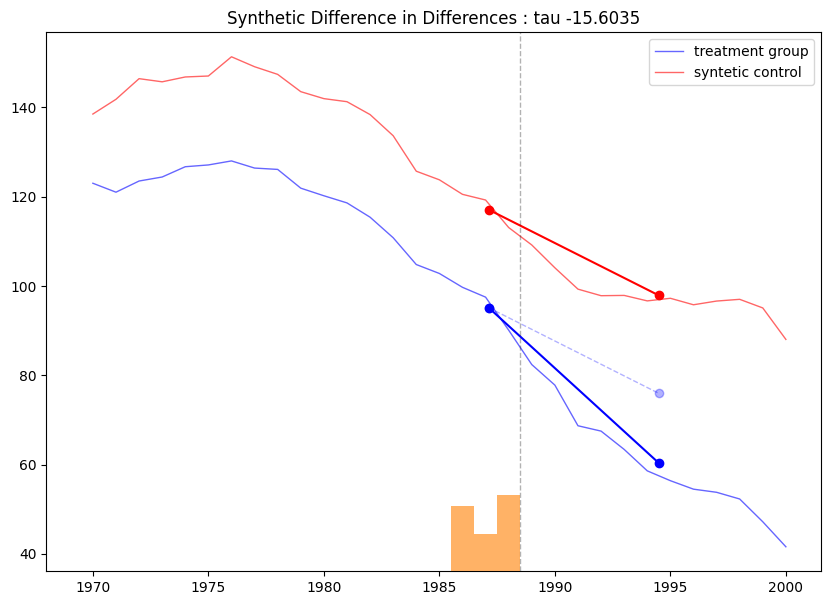

In [3]:
sdid = SynthDID(df, PRE_TEREM, POST_TEREM, TREATMENT)
sdid.fit(zeta_type="base")
sdid.plot(model="sdid")

In [7]:
data_sdid = pd.read_csv('../temporary/data_sdid.csv', parse_dates=['time'])

In [21]:
data_sdid

,user_cc,time,outflow,time_number,country_number,BJ,CA,CM,DE,GB,GH,IN,NG,NL,ZA
0,AD,2017-03-12,0.000000,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,AD,2017-03-19,0.000000,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,AD,2017-03-26,0.000000,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,AD,2017-04-02,0.000000,4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,AD,2017-04-09,0.000000,5,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62055,ZW,2022-08-28,0.000000,286,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62056,ZW,2022-09-04,40.063707,287,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62057,ZW,2022-09-11,65.700133,288,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62058,ZW,2022-09-18,12.989633,289,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
data_sdid_pivot = data_sdid.pivot(columns='user_cc', values='outflow')

In [20]:
data_sdid_pivot

user_cc,AD,AE,AF,AG,AI,AL,AM,AO,AR,AS,...,VI,VN,WS,XK,XX,YE,YT,ZA,ZM,ZW
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
62056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.063707
62057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.700133
62058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.989633


In [12]:
pre_term = ['2020-01-01', '2020-04-08']
post_term = ['2020-04-09', '2020-06-07']

treatment = ["US"]

In [15]:
sdid = SynthDID(data_sdid_pivot, pre_term, post_term, treatment)
sdid.fit(zeta_type="base")

------------------------------------------------------------
Syntetic Difference in Differences

point estimate: -63705.070


In [17]:
sdid.summary(model='sdid')

------------------------------------------------------------
Syntetic Difference in Differences

point estimate: -63705.070


In [18]:
sdid.plot(model="sdid")


TypeError: DatetimeLikeArrayMixin.mean() got an unexpected keyword argument 'dtype'